# Barnes Hut Approximation and Direct N-Body Simulation benchmark

In [102]:
import pandas as pd
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

In [103]:
# Read the benchmark data
bh_data = pd.read_csv('./barnes_hut_benchmark_results.csv', sep=',')
bh_data

,Number of Particles,Duration (seconds)
0,100,0.000046
1,500,0.000542
2,1000,0.001538
3,2000,0.001769
4,4000,0.004049
5,8000,0.009213
6,10000,0.011732
7,15000,0.018731
8,20000,0.025587
9,30000,0.049420


In [104]:
direct_data = pd.read_csv('./direct_method_benchmark_results.csv', sep=',')
direct_data

,Number of Particles,Duration (seconds)
0,100,0.000048
1,500,0.000877
2,1000,0.003328
3,2000,0.011730
4,4000,0.054317
5,8000,0.215674
6,10000,0.320299
7,15000,0.734168
8,20000,1.310772
9,30000,2.925272


In [105]:
# get the number of particles
n_particles = bh_data['Number of Particles'].values

# Get the time taken for each method (second column)
bh_time = bh_data.iloc[:,1].values
direct_time = direct_data.iloc[:,1].values 

In [106]:
# n^2 and n log n functions 
x = np.linspace(100, 100000, 1000)
n_squared = (x**2 - x) / 2  # n^2 - n / 2
n_log_n = x * np.log2(x)

In [107]:
# Make a plot 
plt.style.use(['science', 'ieee', 'no-latex', 'high-vis'])

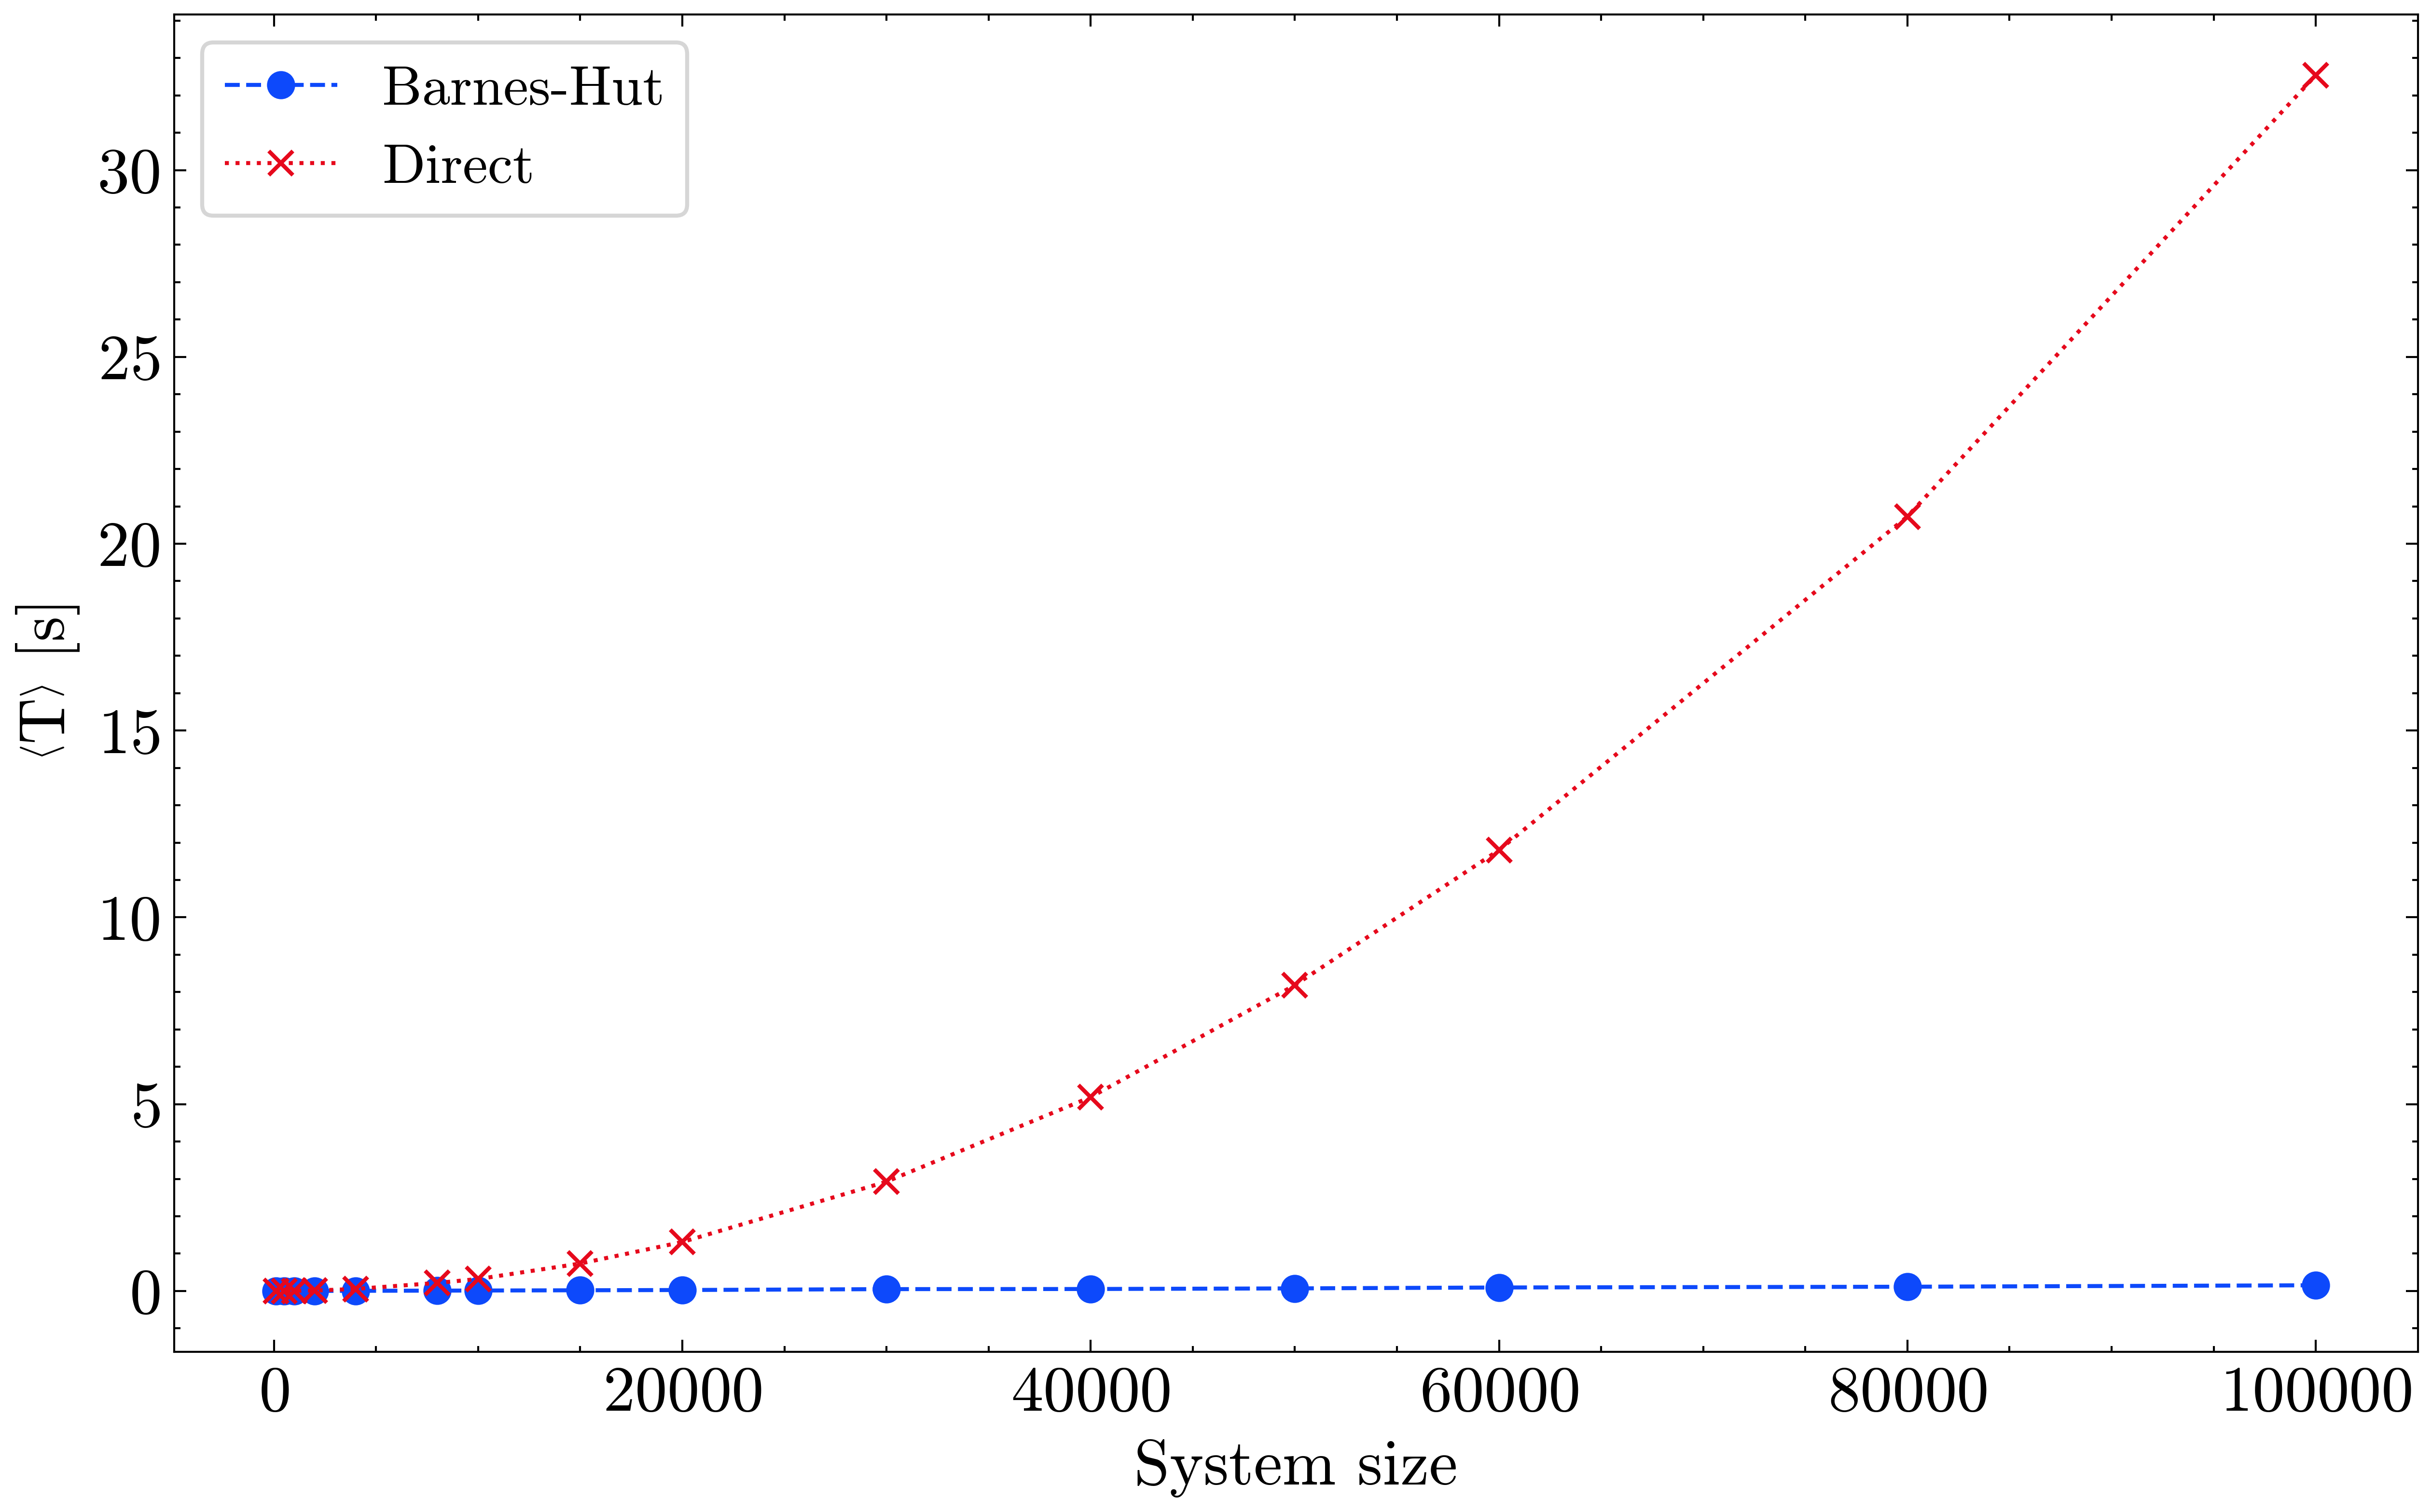

In [124]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_particles, bh_time, label='Barnes-Hut',ls = '--', marker='o')
ax.plot(n_particles, direct_time, label='Direct',ls = ':', marker='x')
#ax.plot(x, n_squared, label='$O(n^2)$', linestyle='--', color='gray')
#ax.plot(x, n_log_n, label='$O(n \log n)$', linestyle='--', color='orange')
#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel('System size')
ax.set_ylabel(r"$\left< \text{T}\right>$ [s]")
#ax.set_title('Barnes-Hut vs Direct Method Benchmark')
ax.legend(loc='upper left', frameon=True, fontsize = 14)
plt.savefig('../report-presentation/figures/benchmark_results_nolog.png', dpi=300, transparent = True)
plt.show()

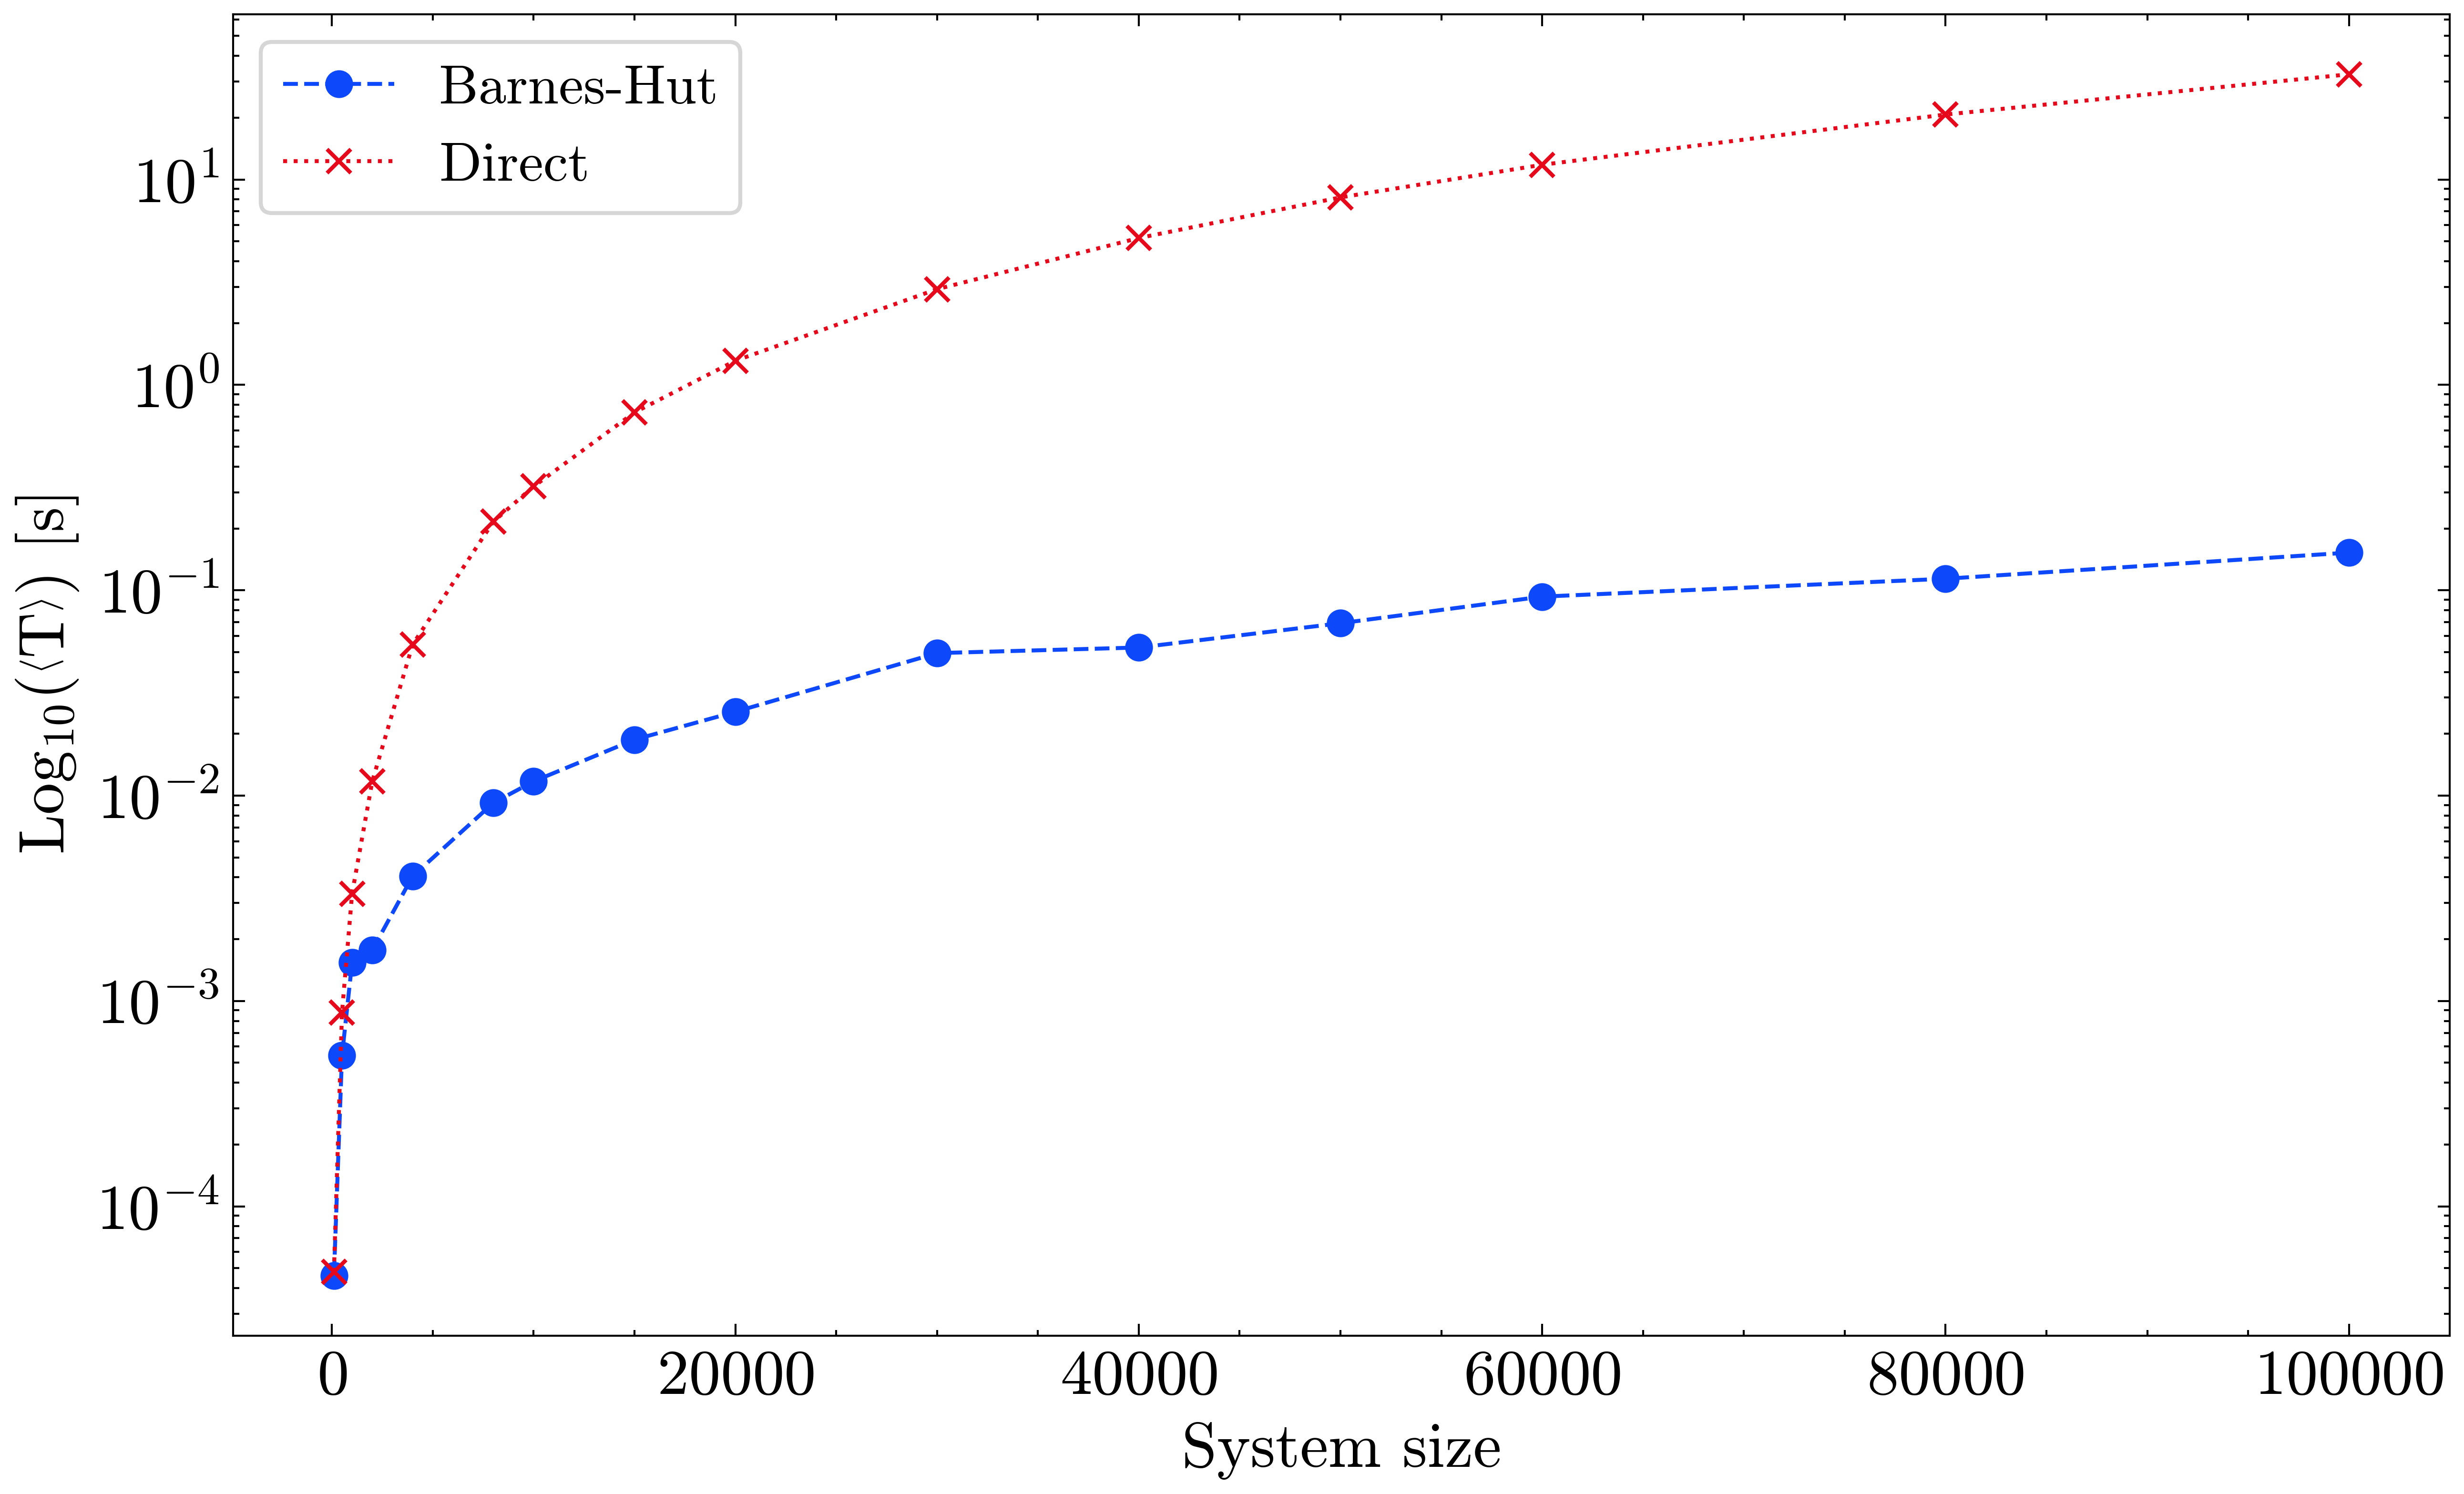

In [123]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_particles, bh_time, label='Barnes-Hut',ls = '--', marker='o')
ax.plot(n_particles, direct_time, label='Direct',ls = ':', marker='x')
#ax.plot(x, n_squared, label='$O(n^2)$', linestyle='--', color='gray')
#ax.plot(x, n_log_n, label='$O(n \log n)$', linestyle='--', color='orange')
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('System size')
ax.set_ylabel(r'Log$_{10}$($\left< \text{T}\right>$) [s]')
#ax.set_title('Barnes-Hut vs Direct Method Benchmark')
ax.legend(loc='upper left', frameon=True, fontsize = 14)
# save the image without background

plt.savefig('../report-presentation/figures/benchmark_results.png', dpi=300, transparent = True)
plt.show()

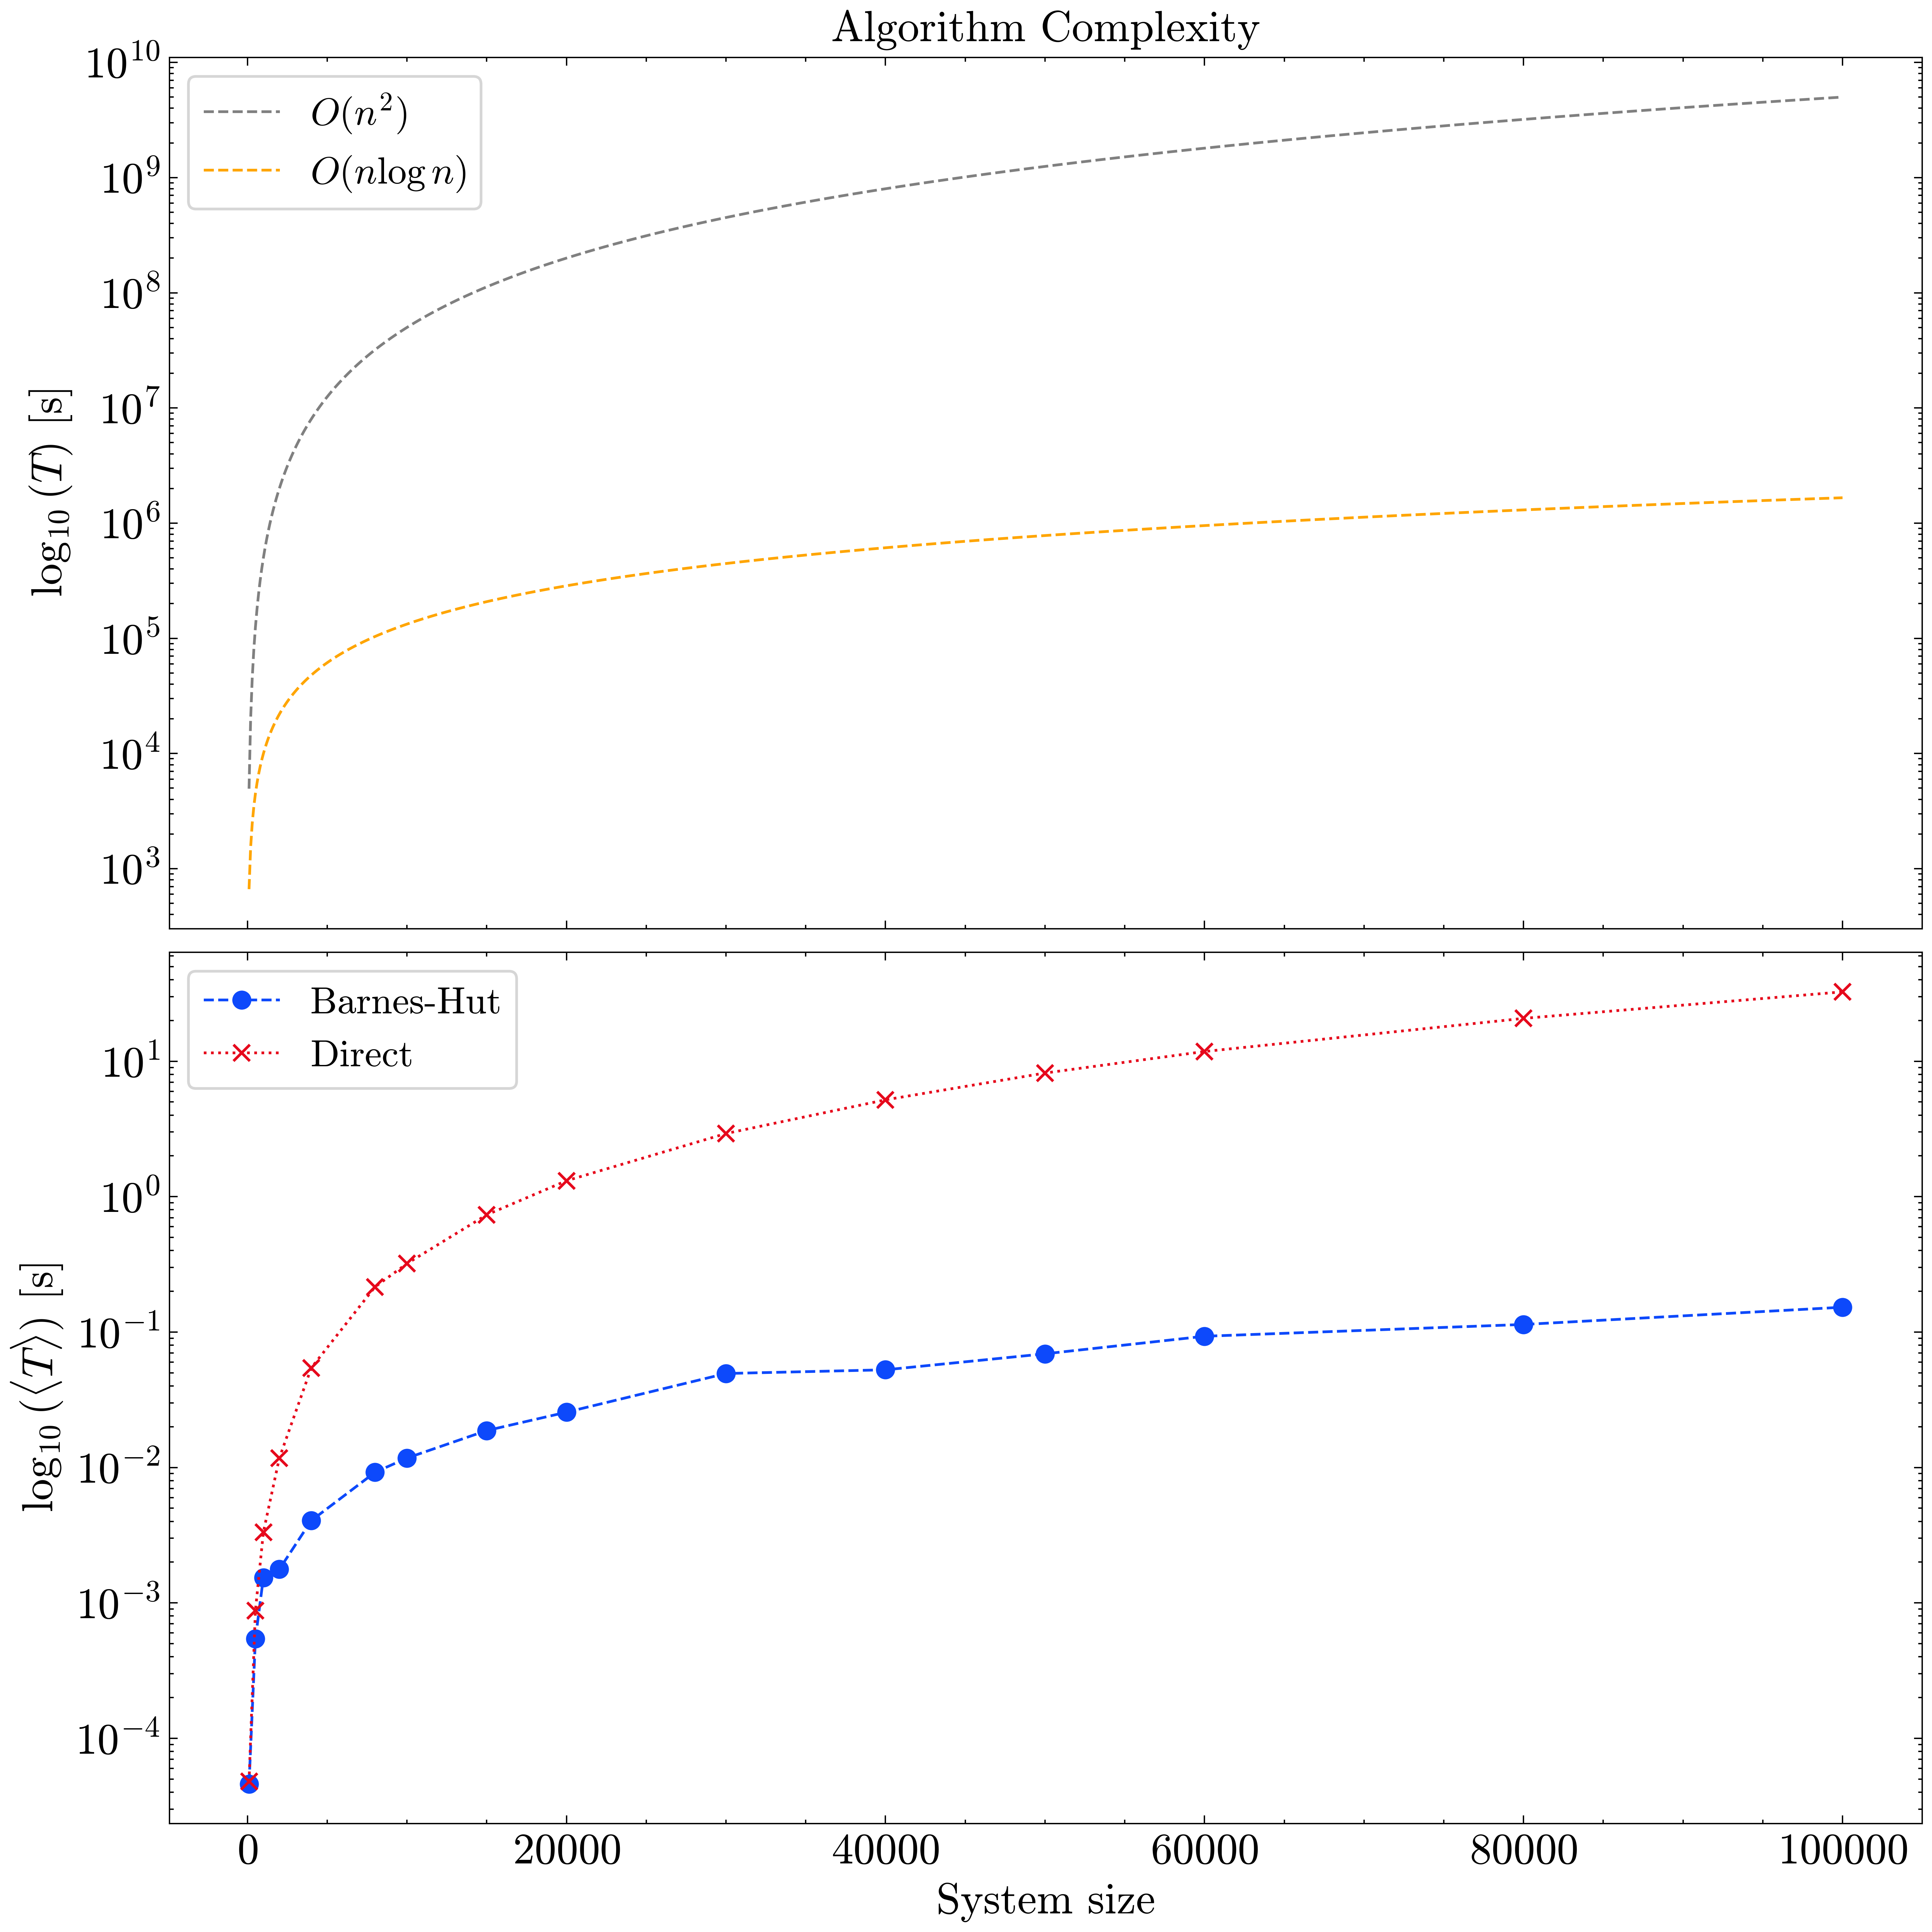

In [130]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# First subplot
axs[0].plot(x, n_squared, label='$O(n^2)$', linestyle='--', color='gray')
axs[0].plot(x, n_log_n, label='$O(n \log n)$', linestyle='--', color='orange')
axs[0].set_ylabel(r'$\log_{10}(T)$ [s]')
axs[0].set_yscale('log')
axs[0].set_title('Algorithm Complexity')
axs[0].legend(loc='upper left', frameon=True, fontsize=14)

# Second subplot
axs[1].plot(n_particles, bh_time, label='Barnes-Hut', ls='--', marker='o')
axs[1].plot(n_particles, direct_time, label='Direct', ls=':', marker='x')
axs[1].set_xlabel('System size')
axs[1].set_ylabel(r'$\log_{10}(\langle T \rangle)$ [s]')
axs[1].set_yscale('log')
axs[1].legend(loc='upper left', frameon=True, fontsize=14)

# Adjust layout to reduce spacing
plt.tight_layout()
plt.savefig('../report-presentation/figures/benchmark_results_complexity_theory.png', dpi=300, transparent=True)
plt.show()
